In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pathlib
import numpy as np
import tifffile
import scipy
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pycoda.registration.elastic_registration import register_coordinates, _invert_d

In [3]:
root_dir = pathlib.Path("/Users/margareteminizer/Desktop/coda/sample_dataset/20x files/1x")
test_file_stem = "lungs_135"
image_jpg_path = root_dir / "registered" / f"{test_file_stem}.jpg"
elastic_registration_filepath = root_dir / "registered" / "elastic registration" /"save_warps"/"D"/f"{test_file_stem}.mat"

In [4]:
image = np.array(Image.open(image_jpg_path))

In [5]:
scale = 20
coords = np.array([[31, 25], [54, 25], [22, 44], [45, 68]])

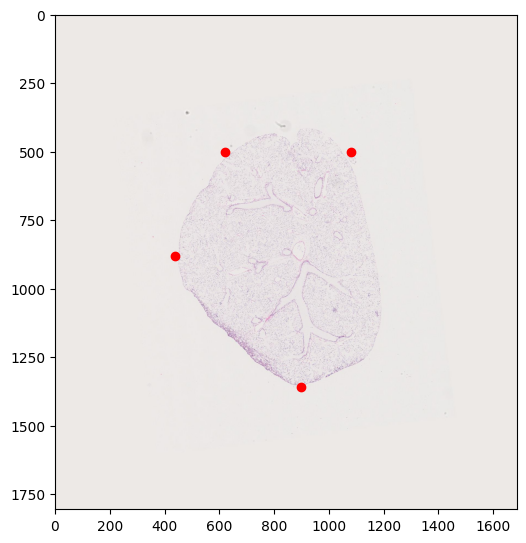

In [6]:
f, ax = plt.subplots(figsize=(6,6*image.shape[0]/image.shape[1]))
ax.imshow(image)
ax.plot(scale*coords[:, 0], scale*coords[:, 1], 'ro')
plt.show()

In [7]:
data = scipy.io.loadmat(elastic_registration_filepath)
D = data["D"]

fillvals, _ = scipy.stats.mode(image, axis=(0, 1))
base_x, base_y = np.meshgrid(
    np.arange(image.shape[1]),
    np.arange(image.shape[0]),
)
map_x = (base_x + D[..., 0]).astype(np.float32)
map_y = (base_y + D[..., 1]).astype(np.float32)
remapped_channels = [
    cv2.remap(
        channel,
        map_x,
        map_y,
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=float(fillvals[i]),
    )
    for i, channel in enumerate(cv2.split(image))
]
image_registered = cv2.merge(remapped_channels)

In [8]:
registered_coords = register_coordinates(elastic_registration_filepath, coords, scale, image.shape[:-1])
print(f"registered_coords: {registered_coords}")

registered_coords: [[31.05590572 25.1737447 ]
 [53.71673023 25.10999468]
 [22.19752937 44.30014217]
 [45.07488648 68.12468119]]


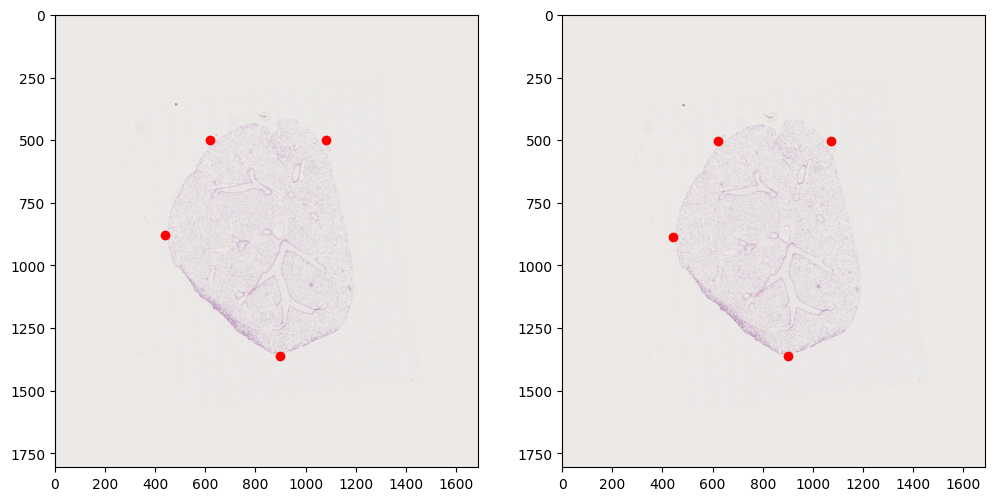

In [9]:
f, ax = plt.subplots(1, 2, figsize=(2*6,6*image.shape[0]/image.shape[1]))
ax[0].imshow(image)
ax[0].plot(scale*coords[:, 0], scale*coords[:, 1], 'ro')
ax[1].imshow(image_registered)
ax[1].plot(scale*registered_coords[:, 0], scale*registered_coords[:, 1], 'ro')
plt.show()